# notebook 3, clustering: grouping markets by price behaviour

the question. forget regions for a second. if we look only at what each market
charges for each commodity, do markets fall into natural groups?

why this is useful. if yes, we can describe cameroon's markets in just a
handful of "types" instead of 76 individual cases. that's the whole point of
clustering, summarising many things into a few groups.

how.
1. we use k means, the simplest clustering algorithm. it picks k centre points
   and assigns each market to its nearest centre, then re computes the centres,
   and repeats until stable.
2. to choose k we use two methods together: the elbow plot (where adding more
   clusters stops helping much) and the silhouette score (how well separated
   the clusters are). using both is more honest than using one alone.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('wfp_food_prices_clean.csv')
print('loaded:', df.shape)

loaded: (55660, 18)


In [2]:
# build a table: each row = one market, each column = median price of a commodity
pivot = df.pivot_table(index='market', columns='commodity', values='price', aggfunc='median')

# keep only commodities present in at least 30% of markets
pivot = pivot.dropna(thresh=int(0.3 * len(pivot)), axis=1)
pivot = pivot.fillna(pivot.median())  # fill remaining gaps

# standardise — so expensive commodities don't dominate
scaler = StandardScaler()
X = scaler.fit_transform(pivot)
print('market price matrix:', pivot.shape)

market price matrix: (76, 38)


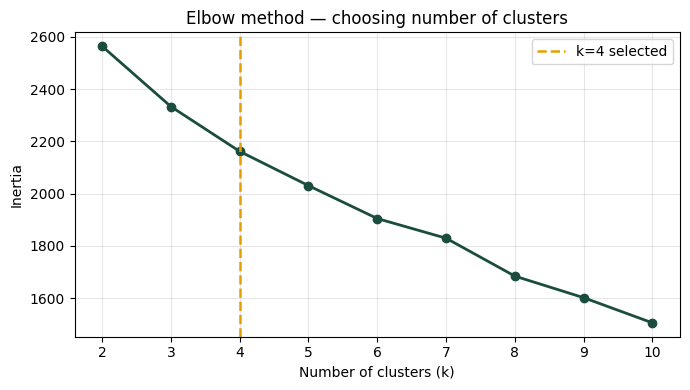

In [3]:
# elbow method: try k=2 to 10 and see where inertia stops dropping
inertias = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(2,11), inertias, marker='o', color='#1B4D3E', linewidth=2)
plt.axvline(x=4, color='#E69F00', linestyle='--', linewidth=1.8, label='k=4 selected')
plt.title('Elbow method — choosing number of clusters')
plt.xlabel('Number of clusters (k)'); plt.ylabel('Inertia')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

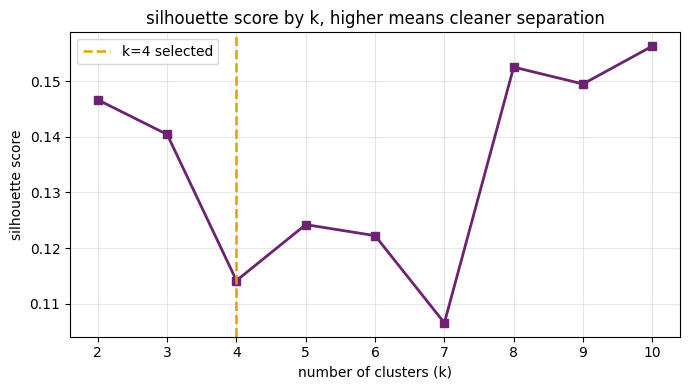

silhouette at k=4: 0.114


In [4]:
# silhouette score, a second opinion on the number of clusters
# range minus 1 to plus 1, higher means clusters are more distinct
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 11):
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_test.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(7,4))
plt.plot(range(2,11), sil_scores, marker='s', color='#6D2370', linewidth=2)
plt.axvline(x=4, color='#E69F00', linestyle='--', linewidth=1.8, label='k=4 selected')
plt.title('silhouette score by k, higher means cleaner separation')
plt.xlabel('number of clusters (k)'); plt.ylabel('silhouette score')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print(f'silhouette at k=4: {sil_scores[2]:.3f}')


In [5]:
# fit k-means with k=4
km = KMeans(n_clusters=4, random_state=42, n_init=20)
km.fit(X)
pivot['cluster'] = km.labels_

print('cluster sizes:')
print(pivot['cluster'].value_counts().sort_index())
print()
# show which markets are in each cluster
for c in range(4):
    markets = pivot[pivot['cluster'] == c].index.tolist()
    print(f'cluster {c}: {", ".join(markets[:6])}{"..." if len(markets)>6 else ""}')

cluster sizes:
cluster
0    18
1    24
2     9
3    25
Name: count, dtype: int64

cluster 0: Amchidé, Doukoula, Fotokol, Galim tignère, Garoua, Gazawa...
cluster 1: Bafoussam, Bamenda, Bamenda-Nkwen, Banyo, Batouri, Douala-Bonaberi...
cluster 2: Barombi Kang, Buea, Kumba, Limbé, Mamfé, Mara...
cluster 3: Bamyanga, Batoua Godolé, Bertoua 1, Bertoua 2, Betare Oya, Garoua Boulaï...


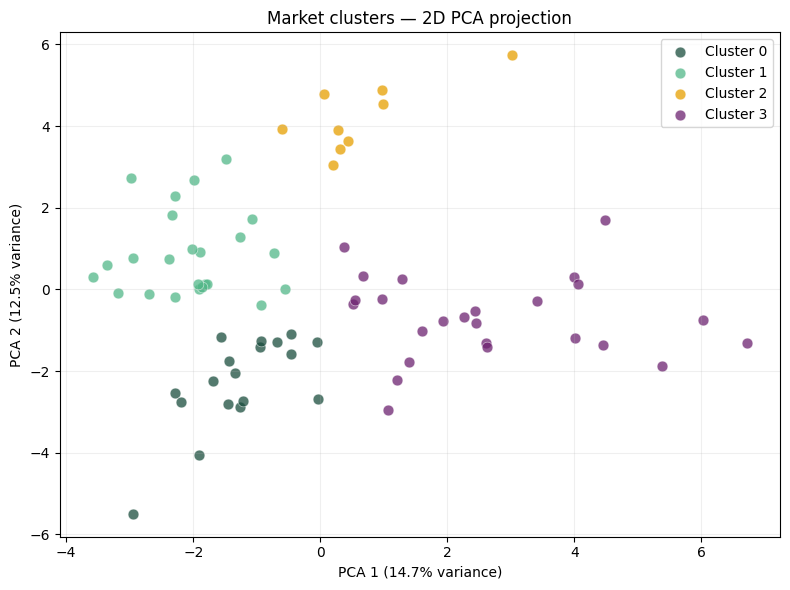

In [6]:
# visualise clusters in 2D using PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
ev = pca.explained_variance_ratio_

colors = ['#1B4D3E','#52B788','#E69F00','#6D2370']
plt.figure(figsize=(8,6))
for c in range(4):
    mask = pivot['cluster'] == c
    plt.scatter(coords[mask,0], coords[mask,1], color=colors[c],
                label=f'Cluster {c}', alpha=0.75, s=60, edgecolors='white', linewidths=0.4)
plt.xlabel(f'PCA 1 ({ev[0]*100:.1f}% variance)')
plt.ylabel(f'PCA 2 ({ev[1]*100:.1f}% variance)')
plt.title('Market clusters — 2D PCA projection')
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

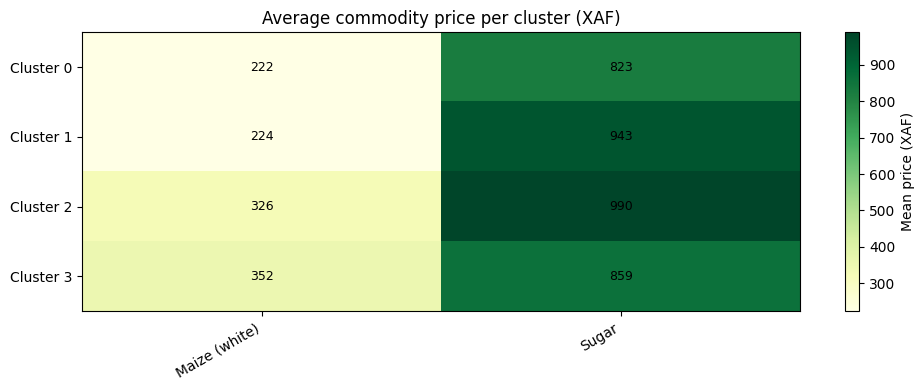

In [7]:
# cluster profile heatmap — what does each cluster eat / pay for?
key_c = [c for c in ['Maize (white)','Cassava','Rice (imported)',
                      'Fish (smoked)','Groundnut oil','Sugar'] if c in pivot.columns]
profile = pivot.groupby('cluster')[key_c].mean()

plt.figure(figsize=(10,4))
plt.imshow(profile.values, cmap='YlGn', aspect='auto')
plt.xticks(range(len(key_c)), key_c, rotation=30, ha='right')
plt.yticks(range(4), [f'Cluster {c}' for c in range(4)])
plt.title('Average commodity price per cluster (XAF)')
plt.colorbar(label='Mean price (XAF)')
for i in range(4):
    for j in range(len(key_c)):
        plt.text(j, i, f'{profile.values[i,j]:.0f}',
                 ha='center', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### what each cluster represents

looking at where the markets are located and what they sell, we can give the
four clusters human readable names:

| cluster | character | typical markets |
|---|---|---|
| 0, far north conflict zone | northern markets affected by boko haram, limited supply, elevated cereal prices | amchidé, fotokol, garoua, maroua |
| 1, major urban hubs | large cities with diverse commodities and stable trade | bafoussam, bamenda, douala bonaberi, yaoundé |
| 2, anglophone southwest | coastal and forest zone markets impacted by the anglophone crisis | buea, kumba, limbé, mamfé |
| 3, eastern refugee corridor | markets near the central african republic with high refugee inflow | bertoua, garoua boulaï, batouri |

the clusters line up with cameroon's three main humanitarian response areas.
in other words, k means rediscovered the country's crisis geography just from
prices. it didn't know anything about politics or conflict.

that's the real value of clustering, it lets the data speak for itself.
